In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import pandas as pd

In [34]:
baseline_order = ['random-rnd', 'oort-rnd', 'poc-rnd']

In [35]:
k_agent = pd.read_csv("./data/k_agent.csv")
literatura = pd.read_csv("./data/normal_sel.csv")

In [36]:
df = pd.concat([k_agent, literatura])

In [37]:
selection_pairs = [
    ("chain-of-thought-oort-llama3.1:8b", "oort-rnd"),
    ("chain-of-thought-oort-qwen3:8b", "oort-rnd"),
    ("chain-of-thought-oort-llama3.2:3b", "oort-rnd"),
    ("chain-of-thought-poc-llama3.1:8b", "poc-rnd"),
    ("chain-of-thought-poc-llama3.2:3b", "poc-rnd"),
    ("chain-of-thought-poc-qwen3:8b", "poc-rnd"),
    ("chain-of-thought-random-llama3.1:8b", "random-rnd"),
    ("chain-of-thought-random-llama3.2:3b", "random-rnd"),
    ("chain-of-thought-random-qwen3:8b", "random-rnd"),


    ("few-shot-oort-llama3.1:8b", "oort-rnd"),
    ("few-shot-oort-qwen3:8b", "oort-rnd"),
    ("few-shot-oort-llama3.2:3b", "oort-rnd"),
    ("few-shot-poc-llama3.1:8b", "poc-rnd"),
    ("few-shot-poc-llama3.2:3b", "poc-rnd"),
    ("few-shot-poc-qwen3:8b", "poc-rnd"),
    ("few-shot-random-llama3.1:8b", "random-rnd"),
    ("few-shot-random-llama3.2:3b", "random-rnd"),
    ("few-shot-random-qwen3:8b", "random-rnd"),

    ("description-only-oort-llama3.1:8b", "oort-rnd"),
    ("description-only-oort-qwen3:8b", "oort-rnd"),
    ("description-only-oort-llama3.2:3b", "oort-rnd"),
    ("description-only-poc-llama3.1:8b", "poc-rnd"),
    ("description-only-poc-llama3.2:3b", "poc-rnd"),
    ("description-only-poc-qwen3:8b", "poc-rnd"),
    ("description-only-random-llama3.1:8b", "random-rnd"),
    ("description-only-random-llama3.2:3b", "random-rnd"),
    ("description-only-random-qwen3:8b", "random-rnd"),


]

reference_times = df.set_index("sel")["sample_time"]

df = pd.DataFrame(
    [
        {
            "sel": left,
            "baseline": right,
            "baseline_time": reference_times[right],
            "sel_time": reference_times[left] - reference_times[right],
            
        }
        for left, right in selection_pairs
    ]
).reset_index(drop=True)

In [38]:
df.head()

,sel,baseline,baseline_time,sel_time
0,chain-of-thought-oort-llama3.1:8b,oort-rnd,0.001135,0.279362
1,chain-of-thought-oort-qwen3:8b,oort-rnd,0.001135,2.215258
2,chain-of-thought-oort-llama3.2:3b,oort-rnd,0.001135,0.189013
3,chain-of-thought-poc-llama3.1:8b,poc-rnd,0.001063,0.260523
4,chain-of-thought-poc-llama3.2:3b,poc-rnd,0.001063,0.195141


In [39]:
# ajustar colunas para facilitar o plot
df['prompt_type'] = df['sel'].apply(lambda x: "-".join(x.split('-')[:-2]))
df['model'] = df['sel'].apply(lambda x: x.split('-')[-1])

In [40]:
df_sorted = df.sort_values('sel_time', ascending=False).reset_index()
df_sorted.head()

,index,sel,baseline,baseline_time,sel_time,prompt_type,model
0,26,description-only-random-qwen3:8b,random-rnd,0.000491,8.657004,description-only,qwen3:8b
1,19,description-only-oort-qwen3:8b,oort-rnd,0.001135,4.457859,description-only,qwen3:8b
2,23,description-only-poc-qwen3:8b,poc-rnd,0.001063,3.999105,description-only,qwen3:8b
3,1,chain-of-thought-oort-qwen3:8b,oort-rnd,0.001135,2.215258,chain-of-thought,qwen3:8b
4,10,few-shot-oort-qwen3:8b,oort-rnd,0.001135,1.973734,few-shot,qwen3:8b


In [41]:
def rename(x):
    if x == 'qwen3:8b':
        return "MQ8b"
    if x == 'llama3.2:3b':
        return "MLL3b"
    if x == 'llama3.1:8b':
        return "MLL8b"
    # return ""
df['model'] = df['model'].apply(rename)

In [42]:
def rename(x):
    if x == 'description-only':
        return "AD"
    if x == 'chain-of-thought':
        return "CoT"
    if x == 'few-shot':
        return "FWP"
df['prompt_type'] = df['prompt_type'].apply(rename)

In [44]:
df.head()

,sel,baseline,baseline_time,sel_time,prompt_type,model
0,chain-of-thought-oort-llama3.1:8b,oort-rnd,0.001135,0.279362,CoT,MLL8b
1,chain-of-thought-oort-qwen3:8b,oort-rnd,0.001135,2.215258,CoT,MQ8b
2,chain-of-thought-oort-llama3.2:3b,oort-rnd,0.001135,0.189013,CoT,MLL3b
3,chain-of-thought-poc-llama3.1:8b,poc-rnd,0.001063,0.260523,CoT,MLL8b
4,chain-of-thought-poc-llama3.2:3b,poc-rnd,0.001063,0.195141,CoT,MLL3b


Random
Oort
Poc
['Random', 'Oort', 'Poc']


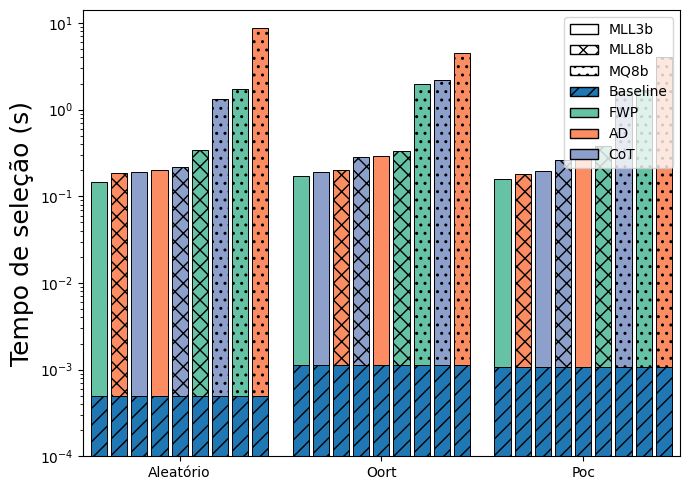

In [ ]:
df_sorted = df.copy()#sort_values(["baseline", "baseline_time",  "model"]).reset_index(drop=True)

group_gap = 1
bar_width = 0.8
x_positions = []
baseline_tick_positions = []
baseline_labels = []
current_x = 0
ordered_sections = []

for baseline in baseline_order:
    section = df_sorted[df_sorted["baseline"] == baseline].sort_values(['sel_time']).reset_index()
    if section.empty:
        continue
    ordered_sections.append(section)
    n_bars = len(section)
    positions = np.arange(current_x, current_x + n_bars)
    x_positions.extend(positions)
    baseline_tick_positions.append(positions.mean())
    baseline_name = baseline.replace("-rnd", "").capitalize()
    # print(baseline_name)
    if baseline_name == 'Random':
        baseline_name = "Random"
    baseline_labels.append(baseline_name)

    current_x = positions[-1] + group_gap + 1

df_sorted = pd.concat(ordered_sections).reset_index(drop=True)
x = np.array(x_positions, dtype=float)

prompt_types = df_sorted["prompt_type"].unique()
palette = sns.color_palette("Set2", n_colors=len(prompt_types))
color_map = dict(zip(prompt_types, palette))
bar_colors = df_sorted["prompt_type"].map(color_map)

hatch_palette = ["", "xx", "..", "++", "||"]
model_hatches = {model: hatch_palette[i % len(hatch_palette)] for i, model in enumerate(df_sorted["model"].unique())}
model_hatch_patterns = df_sorted["model"].map(model_hatches)

fig, ax = plt.subplots(figsize=(7, 5))

baseline_bars = ax.bar(
    x,
    df_sorted["baseline_time"],
    width=bar_width,
    color="#1f77b4",
    hatch="//",
    edgecolor="black",
    linewidth=0.7,
)

sel_bars = ax.bar(
    x,
    df_sorted["sel_time"],
    width=bar_width,
    bottom=df_sorted["baseline_time"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.7,
)

for bar, hatch in zip(sel_bars, model_hatch_patterns):
    bar.set_hatch(hatch)

ax.set_ylabel("Selection time (s)", fontsize=18)
# print(baseline_labels)
ax.set_xticks(baseline_tick_positions)
ax.set_xticklabels(baseline_labels)
ax.set_yscale("log")
ax.set_ylim(bottom=0.0001)
ax.set_xlim(x.min() - bar_width, x.max() + bar_width)

baseline_handle = Patch(facecolor="#1f77b4", edgecolor="black", hatch="//", label="Baseline")
prompt_handles = [
    Patch(facecolor=color_map[p], edgecolor="black", label=p)
    for p in prompt_types
]
component_handles = [baseline_handle, *prompt_handles]
# component_legend = ax.legend(handles=component_handles, loc="upper left")
# ax.add_artist(component_legend)

model_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=model_hatches[m], label=m)
    for m in df_sorted["model"].unique()
]
ax.legend(handles=model_handles+component_handles, loc="upper right")

fig.tight_layout()
fig.savefig("./imgs/tempo-de-selecao.png", dpi=300)

In [10]:
k_agent = pd.read_csv("./data/k_agent.csv")
literatura = pd.read_csv("./data/normal_sel.csv")
df = pd.concat([k_agent, literatura])

In [11]:
selection_pairs = [
    ("chain-of-thought-oort-llama3.1:8b", "oort-rnd"),
    ("chain-of-thought-oort-qwen3:8b", "oort-rnd"),
    ("chain-of-thought-oort-llama3.2:3b", "oort-rnd"),
    ("chain-of-thought-poc-llama3.1:8b", "poc-rnd"),
    ("chain-of-thought-poc-llama3.2:3b", "poc-rnd"),
    ("chain-of-thought-poc-qwen3:8b", "poc-rnd"),
    ("chain-of-thought-random-llama3.1:8b", "random-rnd"),
    ("chain-of-thought-random-llama3.2:3b", "random-rnd"),
    ("chain-of-thought-random-qwen3:8b", "random-rnd"),
]

reference_times = df.set_index("sel")["download_mb"]

df = pd.DataFrame(
    [
        {
            "sel": left,
            "baseline": right,
            "baseline_download": reference_times[right],
            "download_mb": reference_times[left],
            
        }
        for left, right in selection_pairs
    ]
).reset_index(drop=True)

In [12]:
mask = df['sel'].apply(lambda x: 'chain-of-thought' in x)
df = df.loc[mask]

In [13]:
def rename(x):
    return x.replace('chain-of-thought', 'CoT').replace('description-only', "DO").replace("few-shot", "FS")

df['sel'] = df['sel'].apply(rename)

In [14]:
# ajustar colunas para facilitar o plot
df['selection'] = df['sel'].apply(lambda x: x.split('-')[-2])
df['model'] = df['sel'].apply(lambda x: x.split('-')[-1])
df.head()

,sel,baseline,baseline_download,download_mb,selection,model
0,CoT-oort-llama3.1:8b,oort-rnd,130.96,101.60,oort,llama3.1:8b
1,CoT-oort-qwen3:8b,oort-rnd,130.96,107.68,oort,qwen3:8b
2,CoT-oort-llama3.2:3b,oort-rnd,130.96,66.72,oort,llama3.2:3b
3,CoT-poc-llama3.1:8b,poc-rnd,159.36,102.96,poc,llama3.1:8b
4,CoT-poc-llama3.2:3b,poc-rnd,159.36,108.00,poc,llama3.2:3b


In [15]:
df_sorted = df.sort_values('download_mb', ascending=False).reset_index()
df_sorted.head()

,index,sel,baseline,baseline_download,download_mb,selection,model
0,4,CoT-poc-llama3.2:3b,poc-rnd,159.36,108.00,poc,llama3.2:3b
1,1,CoT-oort-qwen3:8b,oort-rnd,130.96,107.68,oort,qwen3:8b
2,3,CoT-poc-llama3.1:8b,poc-rnd,159.36,102.96,poc,llama3.1:8b
3,7,CoT-random-llama3.2:3b,random-rnd,155.36,102.00,random,llama3.2:3b
4,0,CoT-oort-llama3.1:8b,oort-rnd,130.96,101.60,oort,llama3.1:8b


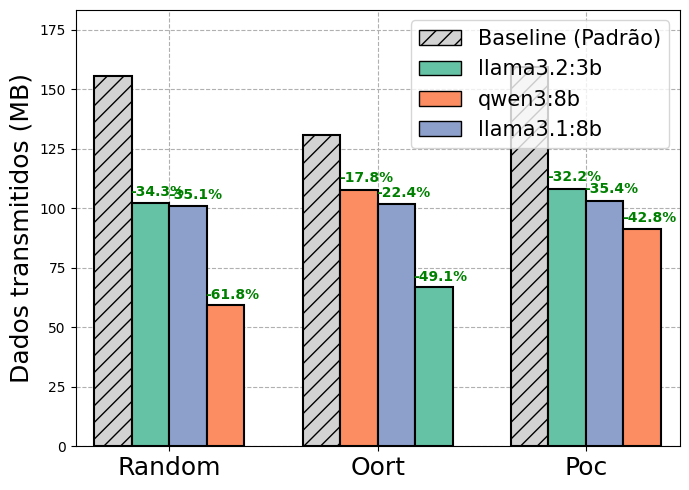

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

baseline_positions = {b: i for i, b in enumerate(baseline_order)}
group_centers = df_sorted['baseline'].map(baseline_positions).astype(float)

bar_width = 0.18
agent_spacing = bar_width * 1
agent_order = df_sorted.groupby('baseline').cumcount() + 1

x_baseline = group_centers
x_agent = group_centers + agent_order * agent_spacing

baseline_once = df_sorted["baseline_download"].where(~df_sorted["baseline"].duplicated(), np.nan)

model_palette = sns.color_palette("Set2", n_colors=df_sorted["model"].nunique())
model_colors = dict(zip(df_sorted["model"].unique(), model_palette))

rects1 = ax.bar(
    x_baseline,
    baseline_once,
    bar_width,
    label="Baseline (Standard)",
    color="#d3d3d3",
    edgecolor="black",
    hatch="//",
    linewidth=1.5,
    zorder=3,
)

rects2 = ax.bar(
    x_agent,
    df_sorted["download_mb"],
    bar_width,
    color=[model_colors[m] for m in df_sorted["model"]],
    edgecolor="black",
    zorder=3,
    linewidth=1.5,
)
for idx, row in df_sorted.iterrows():
    baseline_val = row["baseline_download"]
    agent_val = row["download_mb"]
    diff_val = agent_val - baseline_val
    pct_val = (diff_val / baseline_val) * 100
    text_color = "green" if diff_val < 0 else "red"
    offset = max(agent_val * 0.02, 0.5)
    label_height = agent_val + offset
    ax.annotate(
        f"{pct_val:.1f}%",
        xy=(x_agent.iloc[idx], label_height),
        xytext=(5, 0),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=text_color,
        fontweight="bold",
        fontsize=10,
    )

ax.set_ylabel("Dados transmitidos (MB)", fontsize=18)

group_tick_positions = [
    np.mean([baseline_positions[b]] + x_agent[df_sorted["baseline"] == b].tolist())
    for b in baseline_order
]
ax.set_xticks(group_tick_positions)
ax.set_xticklabels([baseline.replace('-rnd','').capitalize() for baseline in baseline_order], fontsize=18)

ax.grid(zorder=0, linestyle='--')
handles = [
    Patch(facecolor="#d3d3d3", edgecolor="black", hatch="//", label="Baseline (Standard)")
]
handles += [
    Patch(facecolor=model_colors[m], edgecolor="black", label=m)
    for m in df_sorted["model"].unique()
]
ax.legend(handles=handles, fontsize=15)

ax.set_ylim(
    0,
    max(df_sorted["baseline_download"].max(), df_sorted["download_mb"].max()) * 1.15,
)
ax.set_xlim(x_baseline.min() - bar_width, x_agent.max() + bar_width)

plt.tight_layout()
fig.savefig("./imgs/dados-transmitidos.png", dpi=300)